# Question 2

Number of rows: 303, Number of columns: 14

Data types for specific columns:
num_major_vessels    float64
thal                 float64
dtype: object
------------------------------


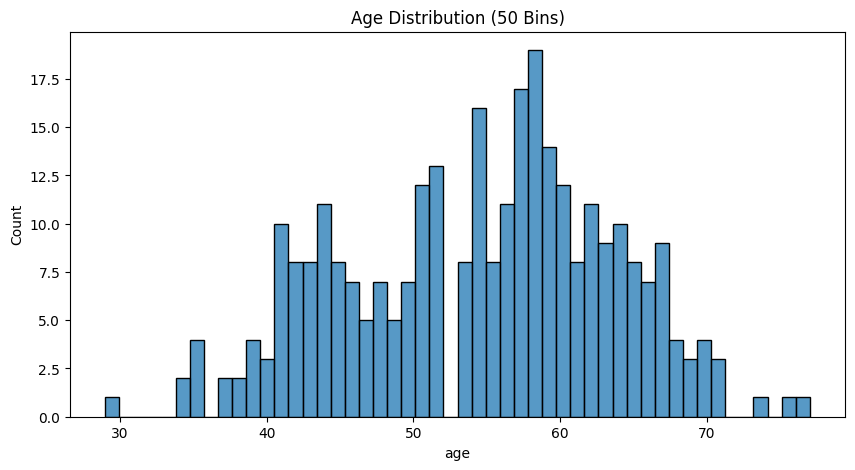

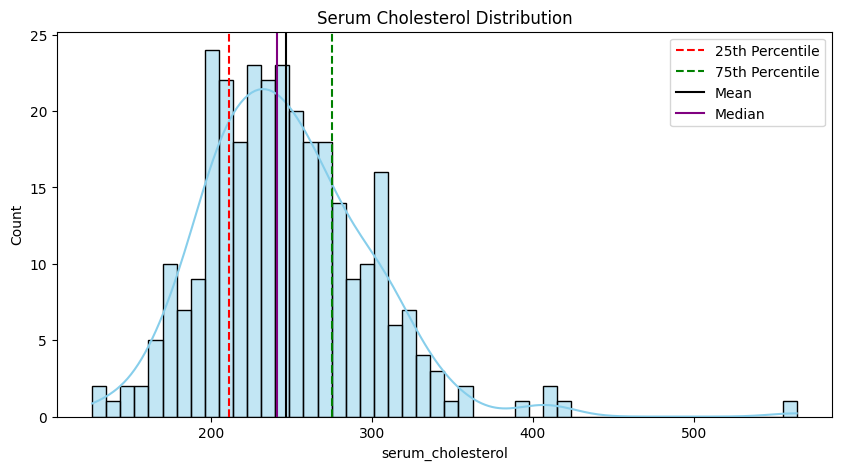

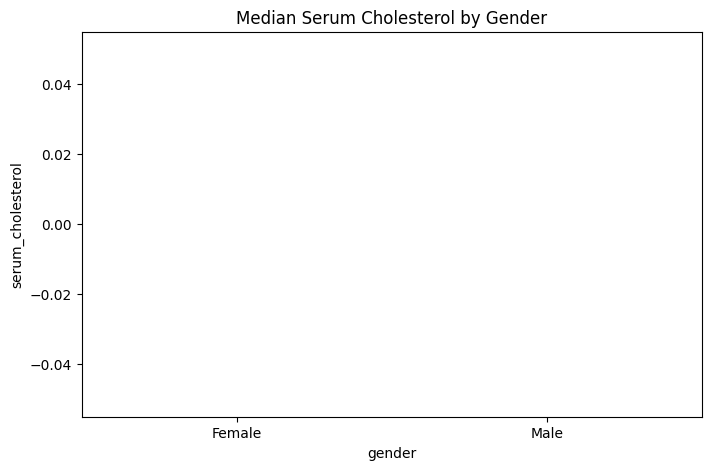

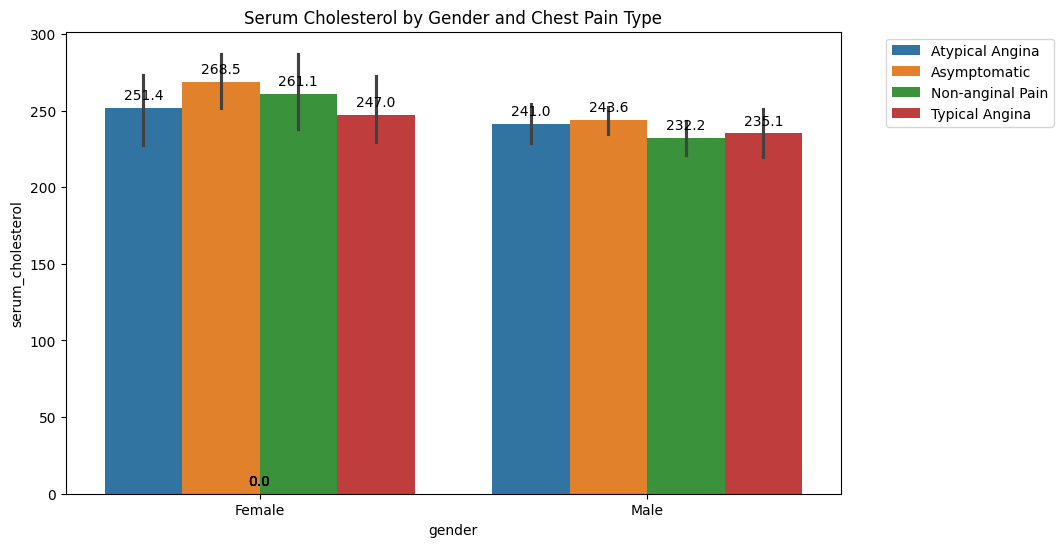

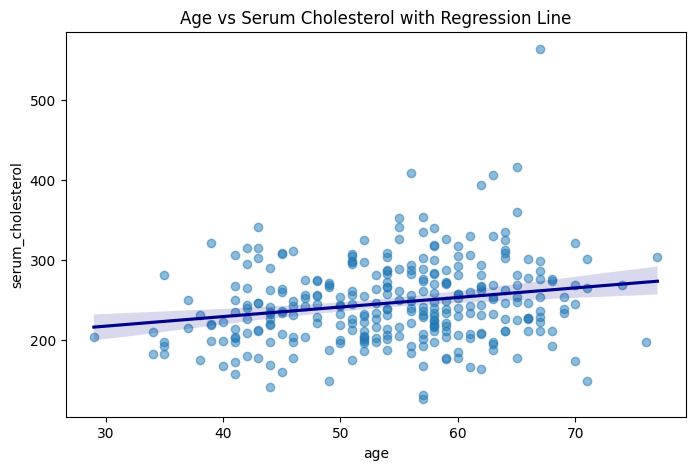

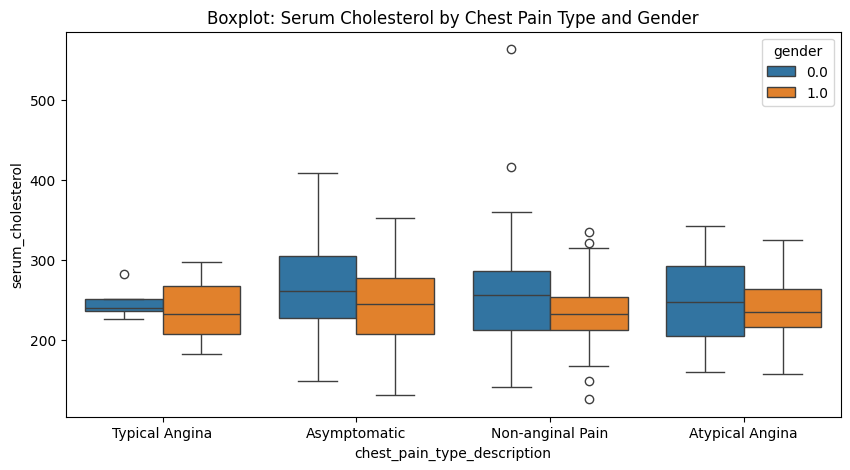

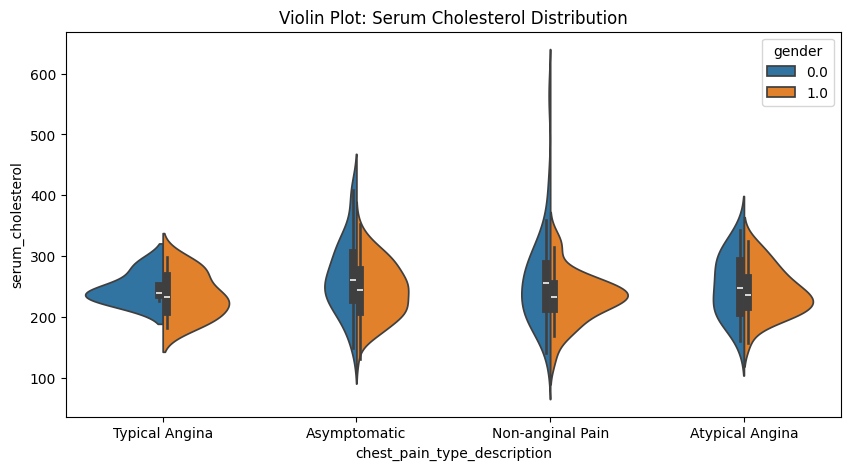

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the 14 headers based on the dataset documentation
column_names = [
    'age', 'gender', 'chest_pain_type', 'resting_blood_pressure',
    'serum_cholesterol', 'fasting_blood_sugar', 'resting_ecg',
    'max_heart_rate', 'exercise_angina', 'oldpeak', 'slope',
    'num_major_vessels', 'thal', 'target'
]

# Load the dataset and assign the headers automatically
# We tell Pandas to treat the '?' character as a missing value (NaN)
df = pd.read_csv('cleveland_heart_attr.csv', names=column_names, na_values='?')

# --- Q2.1: Row and Column count ---
rows, cols = df.shape
print(f"Number of rows: {rows}, Number of columns: {cols}\n")

# --- Q2.2: Checking object types ---
# Note: Because we used na_values='?', these are now correctly parsed as float64
# instead of 'object'. The report explains this behavior.
print("Data types for specific columns:")
print(df[['num_major_vessels', 'thal']].dtypes)
print("-" * 30)

# --- Q2.3 & 4: Histogram on Age ---
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=50, kde=False)
plt.title('Age Distribution (50 Bins)')
plt.show()

# --- Q2.6 & 7: Serum Cholesterol with Percentiles ---
plt.figure(figsize=(10, 5))
sns.histplot(df['serum_cholesterol'], kde=True, bins=50, color='skyblue')
plt.axvline(df['serum_cholesterol'].quantile(0.25), color='red', linestyle='--', label='25th Percentile')
plt.axvline(df['serum_cholesterol'].quantile(0.75), color='green', linestyle='--', label='75th Percentile')
plt.axvline(df['serum_cholesterol'].mean(), color='black', linestyle='-', label='Mean')
plt.axvline(df['serum_cholesterol'].median(), color='purple', linestyle='-', label='Median')
plt.legend()
plt.title('Serum Cholesterol Distribution')
plt.show()

# --- Q2.8 & 9: Bar Plot: Gender vs Serum Cholesterol ---
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='gender', y='serum_cholesterol', order=[0, 1], estimator=np.median)
# Assuming 0 is female and 1 is male based on standard dataset encoding
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.title('Median Serum Cholesterol by Gender')
plt.show()

# --- Q2.11, 12, & 13: Chest Pain Type Mapping and Bar Plot ---
cp_mapping = {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-anginal Pain', 4: 'Asymptomatic'}
df['chest_pain_type_description'] = df['chest_pain_type'].map(cp_mapping)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='gender', y='serum_cholesterol', hue='chest_pain_type_description')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.title('Serum Cholesterol by Gender and Chest Pain Type')

# Adding annotations
for p in ax.patches:
    if pd.notnull(p.get_height()):
        ax.annotate(format(p.get_height(), '.1f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')
plt.show()

# --- Q2.14 & 15: Scatter Plot: Age vs Serum Cholesterol ---
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='age', y='serum_cholesterol', scatter_kws={'alpha':0.5}, line_kws={'color':'darkblue'})
plt.title('Age vs Serum Cholesterol with Regression Line')
plt.show()

# --- Q2.16 & 17: Box Plot ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='chest_pain_type_description', y='serum_cholesterol', hue='gender')
plt.title('Boxplot: Serum Cholesterol by Chest Pain Type and Gender')
plt.show()

# --- Q2.18: Violin Plot ---
plt.figure(figsize=(10, 5))
# For a split violin plot, the hue variable must have exactly two levels.
sns.violinplot(data=df, x='chest_pain_type_description', y='serum_cholesterol', hue='gender', split=True)
plt.title('Violin Plot: Serum Cholesterol Distribution')
plt.show()